In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tifffile import imshow

In [2]:
bell_pepper_img = cv.imread("../../../class.vision/images/felfel-dolme.jpg")

In [4]:
n_clusters = 5
flat_img = np.reshape(bell_pepper_img, (-1, 3))
model =  KMeans(n_clusters=n_clusters)
model.fit(flat_img)
clusters_center = np.uint8(model.cluster_centers_)
labels = model.labels_
print(clusters_center)

[[ 36  78 209]
 [ 12 142  80]
 [ 13  35 128]
 [  2  62  16]
 [  9 183 246]]


In [84]:
count_of_labels = np.bincount(labels)
percentage_of_labels = count_of_labels / len(flat_img) * 100
pl_and_cc = list(zip(percentage_of_labels, clusters_center))
pl_and_cc.sort(reverse=True)
print("percentage_of_labels:", percentage_of_labels)
print("pl_and_cc:", pl_and_cc)

percentage_of_labels: [26.41436825 34.23351046  9.74580381 15.74561404 13.86070344]
pl_and_cc: [(np.float64(34.233510458839405), array([  9, 183, 246], dtype=uint8)), (np.float64(26.414368252361676), array([ 2, 62, 16], dtype=uint8)), (np.float64(15.74561403508772), array([ 36,  77, 208], dtype=uint8)), (np.float64(13.860703441295547), array([ 12, 142,  80], dtype=uint8)), (np.float64(9.745803812415655), array([ 13,  35, 128], dtype=uint8))]


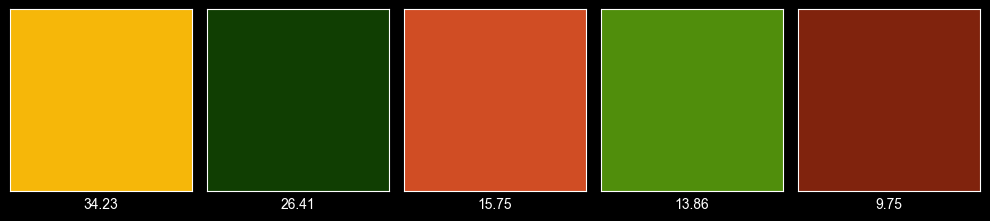

In [85]:
blank = np.zeros((60,60,3), np.uint8)
plt.figure(figsize = (10,4))
for idx, item in enumerate(pl_and_cc):
    plt.subplot(1, n_clusters, idx + 1)
    blank[:] = item[1][::-1]
    plt.imshow(blank)
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(f"{item[0]:0.2f}")

plt.tight_layout()
plt.show()

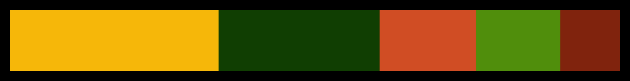

In [98]:
bar = np.zeros((50, 500, 3), np.uint8)

start = 0
for idx, item in enumerate(pl_and_cc):
    end = start + round(item[0] / 100 * 500)
    if idx + 1 == n_clusters:
        bar[:, start:, :] = item[1][::-1]
    else:
        bar[:, start:end, :] = item[1][::-1]
    start = end

plt.imshow(bar)
plt.axis('off'); plt.tight_layout(); plt.show()